In [1]:
from copy import deepcopy
from time import time

import numpy as np

import galsim

import ngmix
from metadetect import do_metadetect

from roman_shear_sims.sim import make_sim
from roman_shear_sims.catalog import GalaxyCatalog, SimpleGalaxyCatalog
from roman_shear_sims.psf_makers import PSFMaker
from roman_shear_sims.constant import IMCOM_BLOCK_SIZE

from metacoadd.metadetect import MetaDetect

In [2]:
import matplotlib.pyplot as plt

In [3]:
seed = 4242
rng = np.random.RandomState(seed)

simu_type = "imcom"
simu_size = IMCOM_BLOCK_SIZE
bands = ["Y106", "J129", "H158"]
gal_type = "gauss"
psf_type = simu_type
layout_kind = "grid"
chromatic=False
spacing = 12.
buff = 200
noise_sig = 1e-5
n_gal = None
gal_mag = 22
gal_hlr = 0.3
flux_range = [100, 1_00]

g1_in = 0.02
g2_in = 0.02

n_epochs = 1

exp_time=107

### Set Galaxy Catalog

In [4]:
# galaxy_catalog = GalaxyCatalog(
#     simu_size,
#     seed,
#     simu_type=simu_type,
#     flux_range=flux_range,
#     layout_kind=layout_kind,
#     exp_time=exp_time,
#     spacing=spacing,
#     buffer=buff,
#     n_gal=n_gal,
#     chromatic=chromatic,
# )
galaxy_catalog = SimpleGalaxyCatalog(
    simu_size,
    seed,
    simu_type=simu_type,
    gal_type=gal_type,
    mag=gal_mag,
    hlr=gal_hlr,
    layout_kind=layout_kind,
    exp_time=exp_time,
    spacing=spacing,
    buffer=buff,
    n_gal=n_gal,
    chromatic=chromatic,
)

### Set the PSF

In [5]:
psf_maker = PSFMaker(
    psf_type=psf_type,
    chromatic=chromatic,
)

### Run the simulation

In [6]:
simu_dict = make_sim(
    rng,
    galaxy_catalog,
    psf_maker,
    simu_type=simu_type,
    n_epochs=n_epochs,
    exp_time=exp_time,
    cell_size_pix=simu_size,
    bands=bands,
    g1=g1_in,
    g2=g2_in,
    chromatic=chromatic,
    simple_noise=True,
    noise_sigma=noise_sig,
    draw_method="fft",
    verbose=True,
)

Band loop:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch loop:   0%|          | 0/1 [00:00<?, ?it/s]

Obj loop:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch loop:   0%|          | 0/1 [00:00<?, ?it/s]

Obj loop:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch loop:   0%|          | 0/1 [00:00<?, ?it/s]

Obj loop:   0%|          | 0/64 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Gaussian profiles')

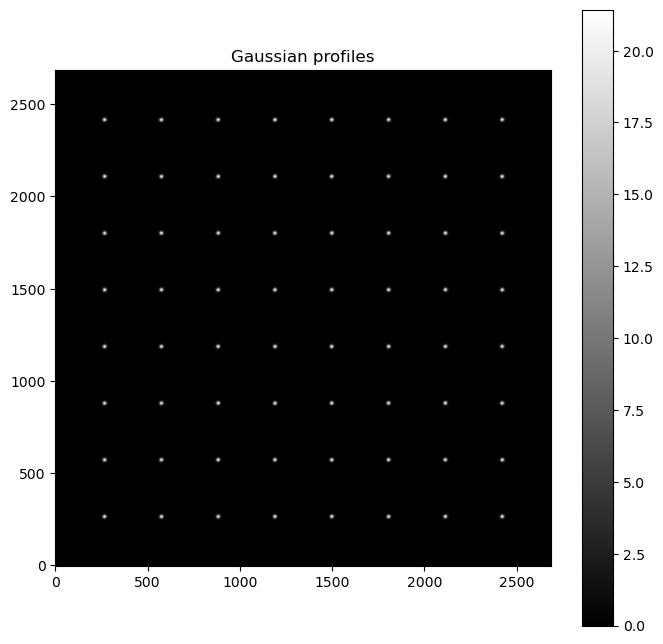

In [7]:
plt.figure(figsize=(8, 8))
plt.imshow(simu_dict["Y106"][0]["sci"][f"shear_{g1_in}_{g2_in}"], origin="lower", cmap="gray")
plt.colorbar()
plt.title("Gaussian profiles")

### Run MetaDetect

In [8]:
# Make Observation
mbobs = ngmix.MultiBandObsList()
for band in bands:
    obslist = ngmix.ObsList()
    for i in range(n_epochs):
        print(f"Processing band {band}, epoch {i}")

        wcs = simu_dict[band][i]["wcs"]
        h = wcs.header
        g_jacob = wcs.jacobian(image_pos=galsim.PositionD(h["CRPIX1"], h["CRPIX2"]))

        img = simu_dict[band][i]["sci"][f"shear_{g1_in}_{g2_in}"]
        img_cen = (np.array(img.shape) - 1) / 2.0
        img_jacob = ngmix.Jacobian(
            row=img_cen[1],
            col=img_cen[0],
            wcs=g_jacob,
        )

        psf_img = simu_dict[band][i]["psf"]
        psf_cen = (np.array(psf_img.shape) - 1) / 2.0
        psf_jacob = ngmix.Jacobian(
            row=psf_cen[1],
            col=psf_cen[0],
            wcs=g_jacob,
        )

        psf_obs = ngmix.Observation(
            image=psf_img,
            jacobian=psf_jacob,
        )

        obs = ngmix.Observation(
            image=img,
            weight=simu_dict["Y106"][0]["weight"],
            noise=simu_dict[band][i]["noise"],
            psf=psf_obs,
            jacobian=img_jacob,
            ormask=np.zeros(img.shape, dtype=np.int32),
            bmask=np.zeros(img.shape, dtype=np.int32),
        )

        obslist.append(obs)
    mbobs.append(obslist)


Processing band Y106, epoch 0
Processing band J129, epoch 0
Processing band H158, epoch 0


In [9]:
mbobs

[[<ngmix.observation.Observation at 0x343917d10>],

In [10]:
model = "gauss"
rng = np.random.RandomState(42)
mdet = MetaDetect(
    rng=rng,
    models=model,
    mcal_config={
        "fixnoise": True,
        "has_pixel": True,
        "types": ["noshear", "1p"],
    },
    fwhm=1.2,
)

In [11]:
if False:
    ts = time()
    final_cat = mdet.go(mbobs)
    print(f"Time to run MetaDetect: {time() - ts:.2f} seconds")

In [12]:
ts = time()
mdet._init_metacal(mbobs)
mcal_mbobs = mdet.mcal_mbobs["noshear"]  # Just for timing comparison
mcal_mbobs = mdet.mcal_mbobs["1p"]
print(f"Time to get mcal mbobs: {time() - ts:.2f} seconds")

Time to get mcal mbobs: 21.90 seconds


In [13]:
ts = time()
mcal_mbobs2 = ngmix.metacal.get_all_metacal(
    mbobs,
    psf="fitgauss",
    rng=np.random.RandomState(42),
    types=["noshear", "1p"],#, "1m", "2p", "2m"],
    use_noise_image=True,
    fixnoise=True,
)
print(f"Time to get mcal mbobs with ngmix: {time() - ts:.2f} seconds")

Time to get mcal mbobs with ngmix: 27.22 seconds


Text(0.5, 1.0, 'Reconv PSF\nMetacoadd - ngmix.metacal')

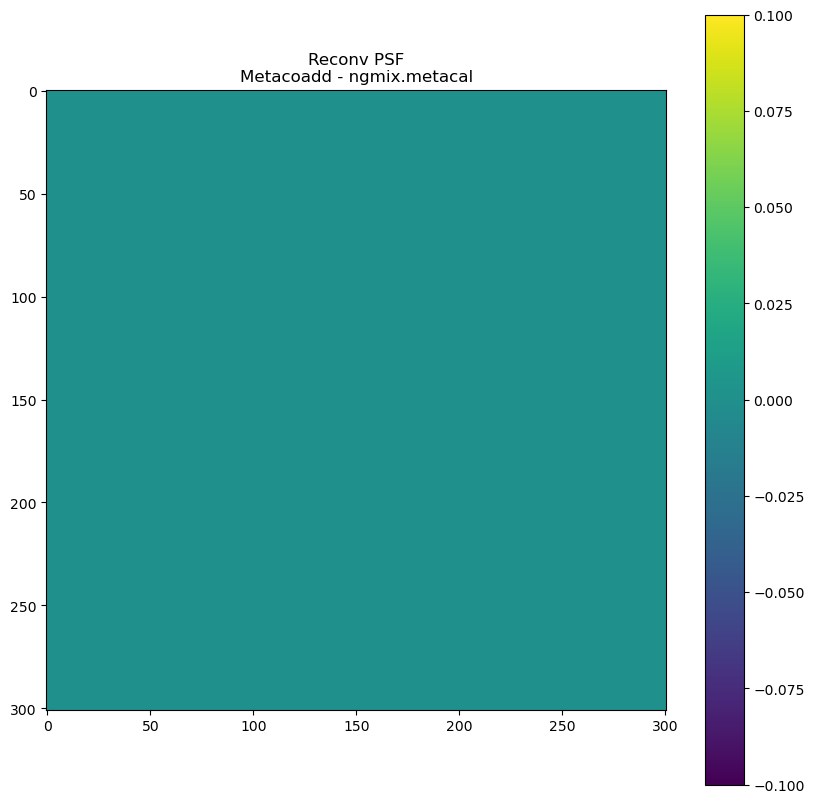

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[0][0].psf.image-mcal_mbobs2["1p"][0][0].psf.image)
plt.colorbar()
plt.title("Reconv PSF\nMetacoadd - ngmix.metacal")

Text(0.5, 1.0, '1p image\nMetacoadd - ngmix.metacal')

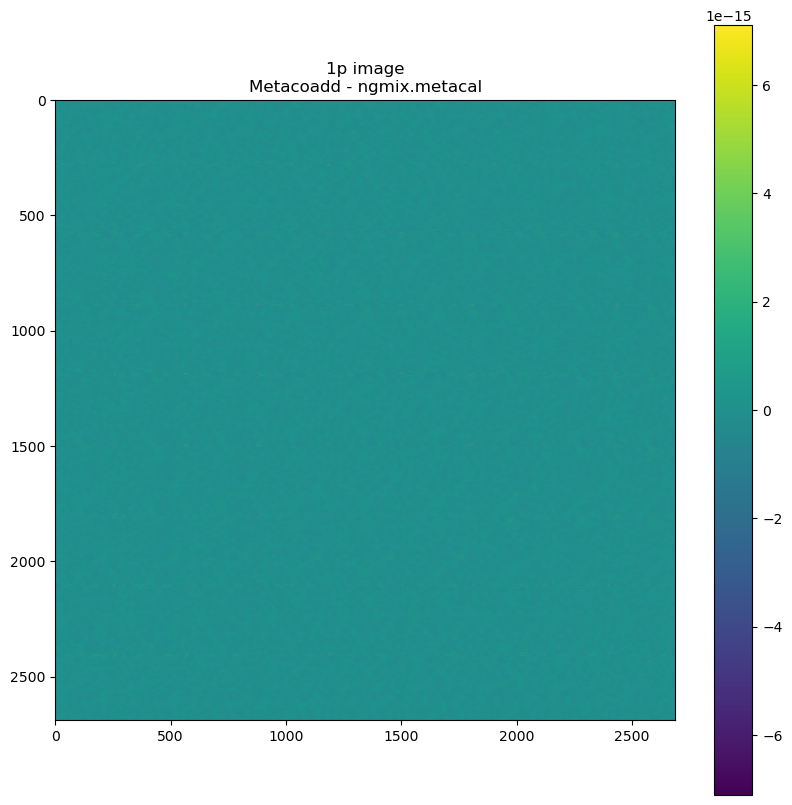

In [15]:
plt.figure(figsize=(10, 10))
plt.imshow(mcal_mbobs[0][0].image-mcal_mbobs2["1p"][0][0].image)
plt.colorbar()
plt.title("1p image\nMetacoadd - ngmix.metacal")

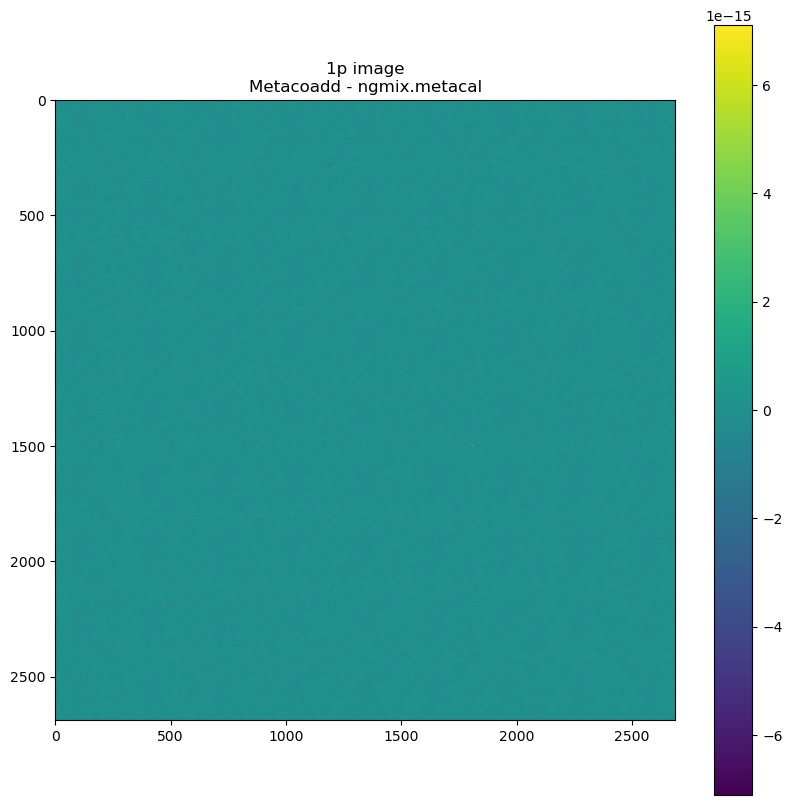

In [16]:
if len(mcal_mbobs) > 1:
    plt.figure(figsize=(10, 10))
    plt.imshow(mcal_mbobs[1][0].image-mcal_mbobs2["1p"][1][0].image)
    plt.colorbar()
    plt.title("1p image\nMetacoadd - ngmix.metacal")

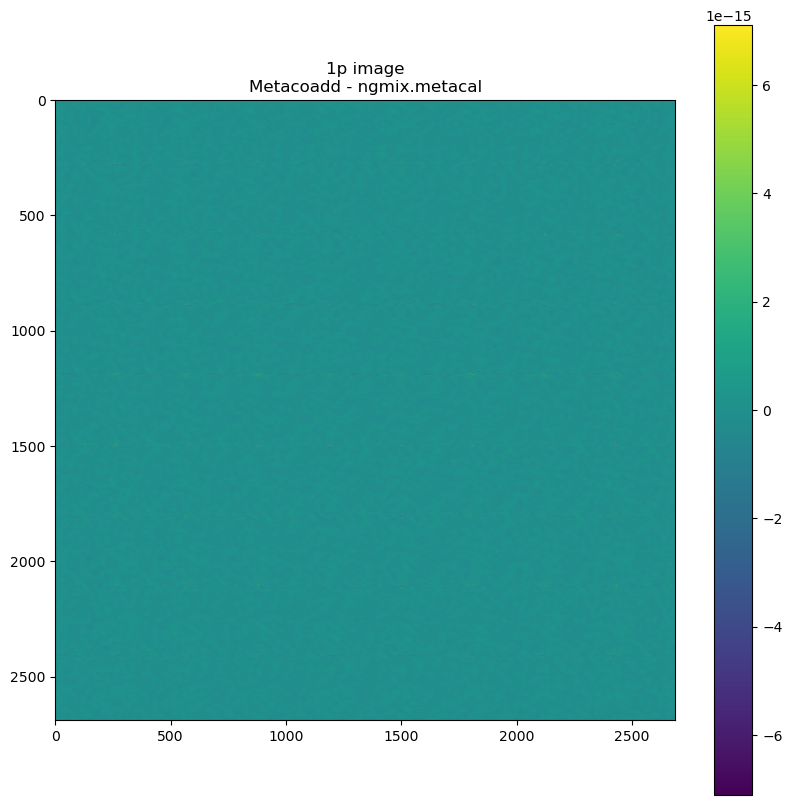

In [17]:
if len(mcal_mbobs) > 2:
    plt.figure(figsize=(10, 10))
    plt.imshow(mcal_mbobs[2][0].image-mcal_mbobs2["1p"][2][0].image)
    plt.colorbar()
    plt.title("1p image\nMetacoadd - ngmix.metacal")

In [18]:
ts = time()
rng = np.random.RandomState(42)
mdet = MetaDetect(
    rng=rng,
    models=model,
    fwhm=1.2,
)
final_cat = mdet.go(mbobs)
print(f"Time to run MetaDetect: {time() - ts:.2f} seconds")

Time to run MetaDetect: 71.18 seconds


In [19]:
final_cat["1p"][f"{model}_g1"]

array([0.02995139, 0.02995366, 0.02995587, 0.02996199, 0.0299579 ,
       0.02996007, 0.02996449, 0.02996658, 0.02996015, 0.0299512 ,
       0.02995362, 0.02995572, 0.0299579 , 0.02996221, 0.02996461,
       0.02996648, 0.02995133, 0.02995352, 0.02995579, 0.02995793,
       0.02996034, 0.02996235, 0.02996445, 0.02996645, 0.02995134,
       0.02995328, 0.02995585, 0.02995793, 0.02996015, 0.02996238,
       0.02996456, 0.0299665 , 0.02995131, 0.02995347, 0.02995569,
       0.02995783, 0.02996015, 0.02996209, 0.0299668 , 0.0299645 ,
       0.02995134, 0.02995773, 0.0299669 , 0.02995329, 0.02995566,
       0.02995981, 0.02996201, 0.02996441, 0.02995356, 0.0299559 ,
       0.02996678, 0.02995113, 0.02995805, 0.02995996, 0.02996229,
       0.02996431, 0.02995365, 0.02995124, 0.02995548, 0.02995791,
       0.02996001, 0.02996205, 0.0299643 , 0.02996692])

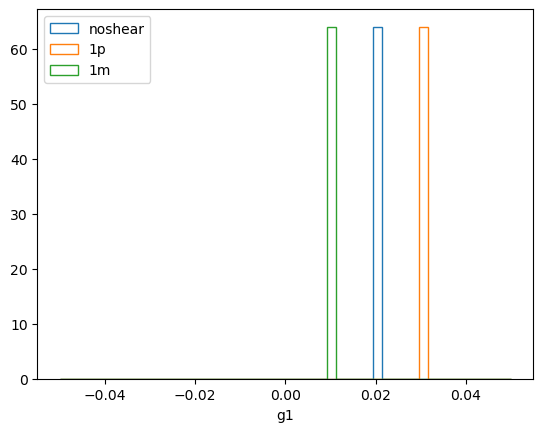

In [20]:
bins = np.linspace(-0.05, 0.05, 50)
plt.hist(final_cat["noshear"][f"{model}_g1"], bins, histtype="step", label="noshear")
plt.hist(final_cat["1p"][f"{model}_g1"], bins, histtype="step", label="1p")
plt.hist(final_cat["1m"][f"{model}_g1"], bins, histtype="step", label="1m")
plt.xlabel("g1")
plt.legend()

### Run "offcial" MetaDetect

In [21]:
# Size of the taget Gaussian PSF in IMCOM
PSF_FWHM = {
    "Y106": 0.22,
    "J129": 0.231,
    "H158": 0.242,
    "F184": 0.253,
    "K213": 0.264,
}
# Size of the image used to draw the PSF
PSF_IMG_SIZE = 151

# Size of one IMCOM block
IMG_SIZE = 2688
# Boundary used to avoid edge effects
# Objects for which the centre is within this distance from the edge will be
# masked out.
BOUND_SIZE = 100

METADETECT_CONFIG = {
    # Shape measurement method
    # wmom: weighted moments
    # "model": "wmom",
    # "model": "gauss",
    "model": model,

    # Size of the weight function for the moments
    'weight': {
        'fwhm': 1.2,  # arcsec
    },

    # Metacal settings
    'metacal': {
        'psf': 'fitgauss',
        # Kind of shear applied to the image
        'types': ['noshear', '1p', '1m', '2p', '2m'],
        'use_noise_image': True,
        'fixnoise': True,
    },

    'sx': {
        # in sky sigma
        # DETECT_THRESH
        'detect_thresh': 1500,

        # Minimum contrast parameter for deblending
        # DEBLEND_MINCONT
        'deblend_cont': 0.005,

        # minimum number of pixels above threshold
        # DETECT_MINAREA: 6
        'minarea': 5,

        'filter_type': 'conv',

        # 7x7 convolution mask of a gaussian PSF with FWHM = 3.0 pixels.
        'filter_kernel': [
            [0.004963, 0.021388, 0.051328, 0.068707, 0.051328, 0.021388, 0.004963],  # noqa
            [0.021388, 0.092163, 0.221178, 0.296069, 0.221178, 0.092163, 0.021388],  # noqa
            [0.051328, 0.221178, 0.530797, 0.710525, 0.530797, 0.221178, 0.051328],  # noqa
            [0.068707, 0.296069, 0.710525, 0.951108, 0.710525, 0.296069, 0.068707],  # noqa
            [0.051328, 0.221178, 0.530797, 0.710525, 0.530797, 0.221178, 0.051328],  # noqa
            [0.021388, 0.092163, 0.221178, 0.296069, 0.221178, 0.092163, 0.021388],  # noqa
            [0.004963, 0.021388, 0.051328, 0.068707, 0.051328, 0.021388, 0.004963],  # noqa
        ]
    },

    # This is for the cutout at each detection
    'meds': {
        'min_box_size': 101,
        'max_box_size': 101,

        'box_type': 'iso_radius',

        'rad_min': 4,
        'rad_fac': 2,
        'box_padding': 2,
    },

    # check for an edge hit
    'bmask_flags': 2**30,

    'nodet_flags': 2**0,
}

In [22]:
ts = time()
res = do_metadetect(
    deepcopy(METADETECT_CONFIG),
    mbobs=mbobs,
    rng=np.random.RandomState(42),
)
print(f'Time to run metadetect "offcial": {time() - ts:.2f} seconds')

Time to run metadetect "offcial": 81.53 seconds


In [23]:
res["1p"][f"{model}_g"][:, 0]

array([0.02995139, 0.02995366, 0.02995587, 0.02996199, 0.02995788,
       0.02996007, 0.0299645 , 0.02996659, 0.02996015, 0.02995117,
       0.02995362, 0.02995572, 0.0299579 , 0.02996221, 0.02996461,
       0.02996648, 0.02995133, 0.02995352, 0.02995579, 0.02995792,
       0.02996034, 0.02996235, 0.02996445, 0.02996645, 0.02995134,
       0.02995328, 0.02995585, 0.02995792, 0.02996015, 0.02996238,
       0.02996456, 0.0299665 , 0.02995131, 0.02995347, 0.02995569,
       0.02995784, 0.02996015, 0.02996209, 0.0299668 , 0.0299645 ,
       0.02995133, 0.02995783, 0.0299669 , 0.02995329, 0.02995566,
       0.02995981, 0.02996201, 0.02996441, 0.02995356, 0.0299559 ,
       0.02996679, 0.02995113, 0.02995805, 0.02995996, 0.02996228,
       0.02996431, 0.02995365, 0.02995125, 0.02995548, 0.02995791,
       0.02996001, 0.02996205, 0.0299643 , 0.02996693])

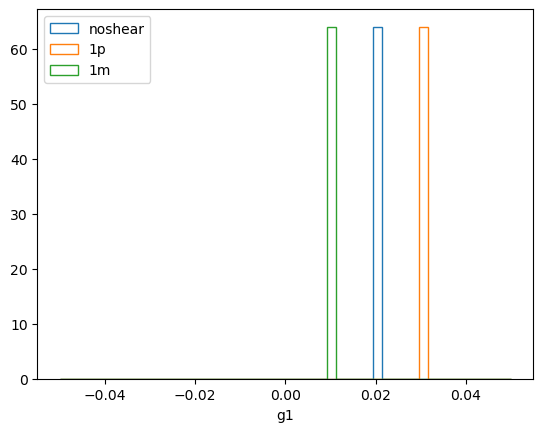

In [24]:
bins = np.linspace(-0.05, 0.05, 50)
plt.hist(res["noshear"][f"{model}_g"][:, 0], bins, histtype="step", label="noshear")
plt.hist(res["1p"][f"{model}_g"][:, 0], bins, histtype="step", label="1p")
plt.hist(res["1m"][f"{model}_g"][:, 0], bins, histtype="step", label="1m")
plt.xlabel("g1")
plt.legend()

### Compare output

In [25]:
print("noshear:", len(final_cat["noshear"]), len(res["noshear"]))
print("1p:", len(final_cat["1p"]), len(res["1p"]))
print("1m:", len(final_cat["1m"]), len(res["1m"]))
print("2p:", len(final_cat["2p"]), len(res["2p"]))
print("2m:", len(final_cat["2m"]), len(res["2m"]))

noshear: 64 64
1p: 64 64
1m: 64 64
2p: 64 64
2m: 64 64


In [26]:
res["noshear"][f"{model}_g"][:, 0]

array([0.01995316, 0.01995539, 0.01995756, 0.01996007, 0.01996229,
       0.01996424, 0.01996896, 0.01996668, 0.01995359, 0.01996198,
       0.01996427, 0.01996884, 0.01995552, 0.01995751, 0.01995988,
       0.0199663 , 0.01995351, 0.01995979, 0.01996889, 0.01995551,
       0.01995755, 0.01996201, 0.01996414, 0.01996657, 0.01995336,
       0.01995564, 0.01995761, 0.01995987, 0.019962  , 0.01996425,
       0.01996639, 0.01996876, 0.01995317, 0.0199554 , 0.01995767,
       0.0199599 , 0.01996206, 0.01996457, 0.01996666, 0.01996853,
       0.01995333, 0.0199557 , 0.0199601 , 0.01996653, 0.01996859,
       0.01995761, 0.01996231, 0.01996445, 0.01995537, 0.01995754,
       0.01996226, 0.01996863, 0.01995319, 0.0199598 , 0.01996414,
       0.01996652, 0.01995553, 0.01995999, 0.01996662, 0.01995332,
       0.01995777, 0.019962  , 0.01996429, 0.01996869])

Text(0.5, 1.0, 'g1 for noshear')

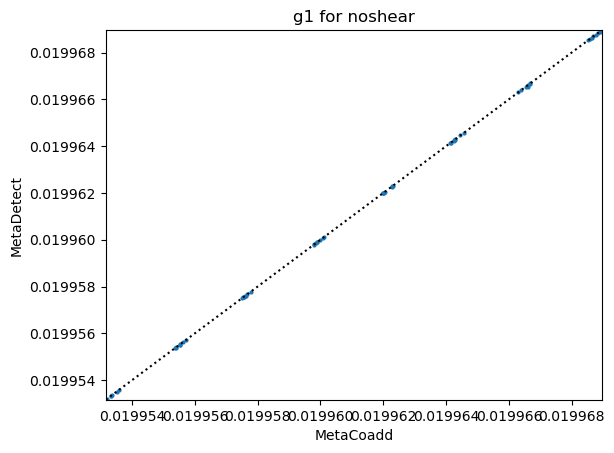

In [27]:
vmin = np.min([final_cat["noshear"][f"{model}_g1"], res["noshear"][f"{model}_g"][:, 0]])
vmax = np.max([final_cat["noshear"][f"{model}_g1"], res["noshear"][f"{model}_g"][:, 0]])
plt.plot(final_cat["noshear"][f"{model}_g1"], res["noshear"][f"{model}_g"][:, 0], "o", markersize=2,)
plt.axline((0., 0.), slope=1, color="k", linestyle=":")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("g1 for noshear")

Text(0.5, 1.0, 'g1 for noshear')

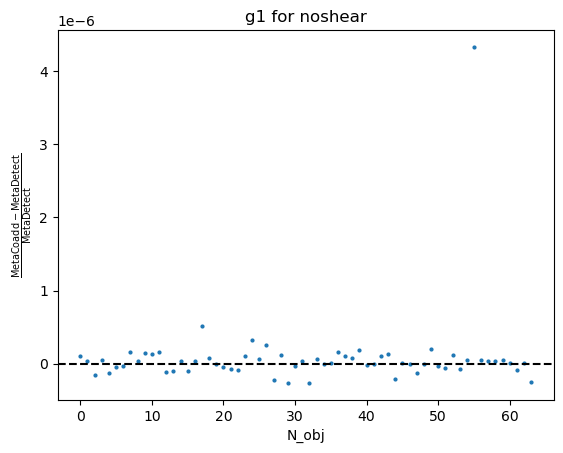

In [28]:
plt.plot((final_cat["noshear"][f"{model}_g1"]-res["noshear"][f"{model}_g"][:, 0])/res["noshear"][f"{model}_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("N_obj")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for noshear")

Text(0.5, 1.0, 'g1 for 1p')

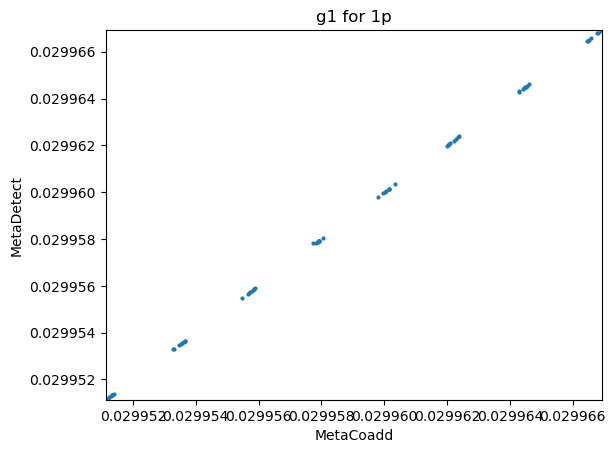

In [29]:
vmin = np.min([final_cat["1p"][f"{model}_g1"], res["1p"][f"{model}_g"][:, 0]])
vmax = np.max([final_cat["1p"][f"{model}_g1"], res["1p"][f"{model}_g"][:, 0]])
plt.plot(final_cat["1p"][f"{model}_g1"], res["1p"][f"{model}_g"][:, 0], "o", markersize=2, label="noshear")
plt.axvline(0.01, color="k", linestyle="--")
plt.axhline(0.01, color="k", linestyle="--")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("g1 for 1p")

Text(0.5, 1.0, 'g1 for 1p')

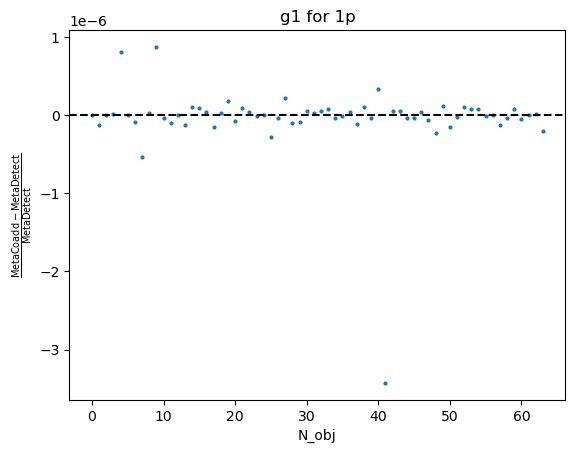

In [30]:
plt.plot((final_cat["1p"][f"{model}_g1"]-res["1p"][f"{model}_g"][:, 0])/res["1p"][f"{model}_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("N_obj")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 1p")

Text(0, 0.5, 'MetaDetect')

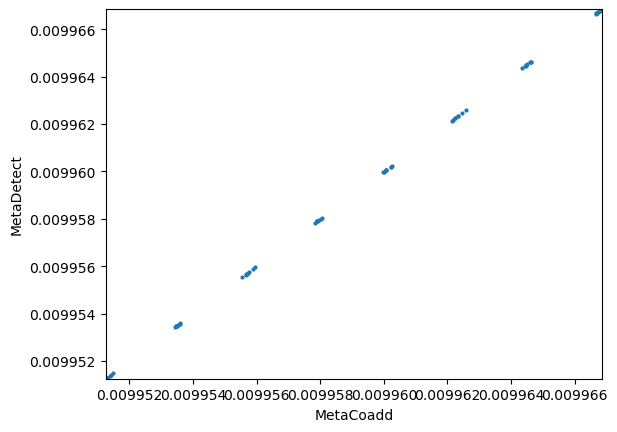

In [31]:
vmin = np.min([final_cat["1m"][f"{model}_g1"], res["1m"][f"{model}_g"][:, 0]])
vmax = np.max([final_cat["1m"][f"{model}_g1"], res["1m"][f"{model}_g"][:, 0]])
plt.plot(final_cat["1m"][f"{model}_g1"], res["1m"][f"{model}_g"][:, 0], "o", markersize=2, label="noshear")
plt.axvline(-0.01, color="k", linestyle="--")
plt.axhline(-0.01, color="k", linestyle="--")
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")

Text(0.5, 1.0, 'g1 for 1m')

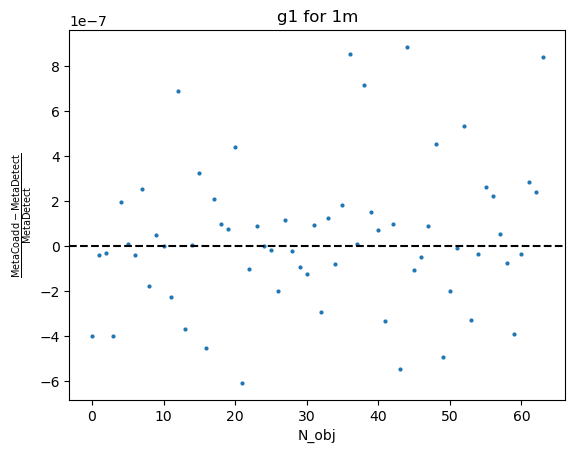

In [32]:
plt.plot((final_cat["1m"][f"{model}_g1"]-res["1m"][f"{model}_g"][:, 0])/res["1m"][f"{model}_g"][:, 0], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("N_obj")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g1 for 1m")

Text(0.5, 1.0, 'g2 for 2m')

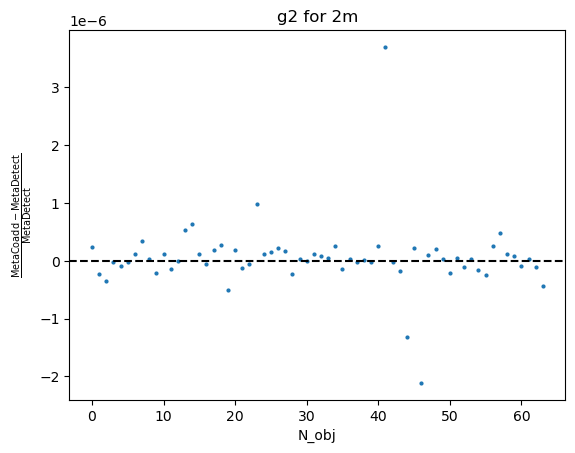

In [33]:
plt.plot((final_cat["2m"][f"{model}_g2"]-res["2m"][f"{model}_g"][:, 1])/res["2m"][f"{model}_g"][:, 1], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("N_obj")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("g2 for 2m")

Text(0.5, 1.0, 'T for 1m')

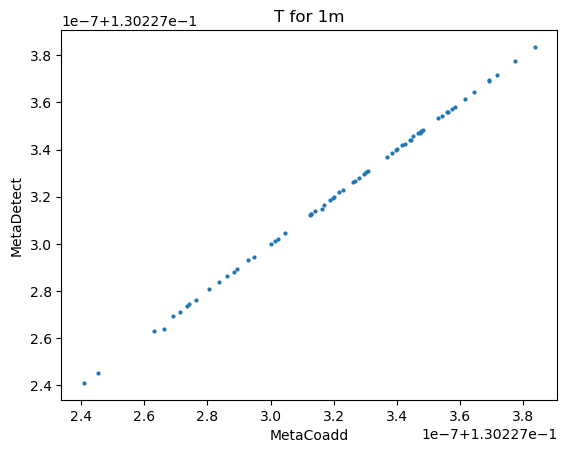

In [34]:
plt.plot(final_cat["1m"][f"{model}_T"], res["1m"][f"{model}_T"], "o", markersize=2, label="noshear")
# plt.axis('equal')
plt.xlabel("MetaCoadd")
plt.ylabel("MetaDetect")
plt.title("T for 1m")

Text(0.5, 1.0, 'T for noshear')

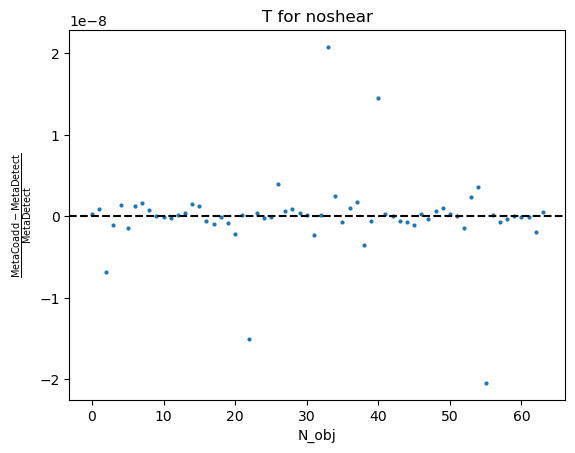

In [35]:
plt.plot((final_cat["noshear"][f"{model}_T"]-res["noshear"][f"{model}_T"])/res["noshear"][f"{model}_T"], "o", markersize=2,)
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("N_obj")
plt.ylabel(r"$\frac{\rm{MetaCoadd} - \rm{MetaDetect}}{\rm{MetaDetect}}$")
plt.title("T for noshear")

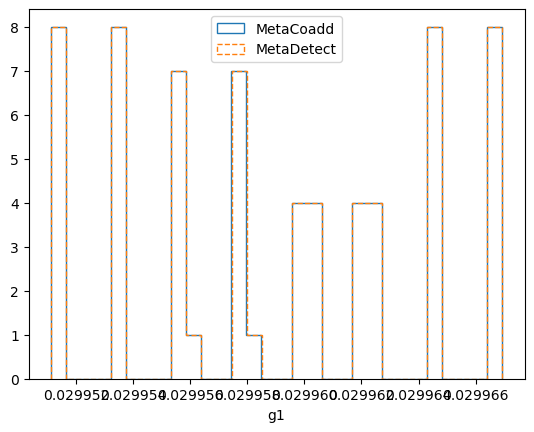

In [36]:
key = "1p"
good_mc = (final_cat[key][f"{model}_flags"] == 0) & (final_cat[key][f"{model}_s2n"] > 10)
good_md = (res[key][f"{model}_flags"] == 0) & (res[key][f"{model}_s2n"] > 10)
plt.hist(final_cat[key][f"{model}_g1"][good_mc], 30, histtype="step", label="MetaCoadd")
plt.hist(res[key][f"{model}_g"][good_md, 0], 30, histtype="step", label="MetaDetect", linestyle="--")
plt.xlabel("g1")
plt.legend()

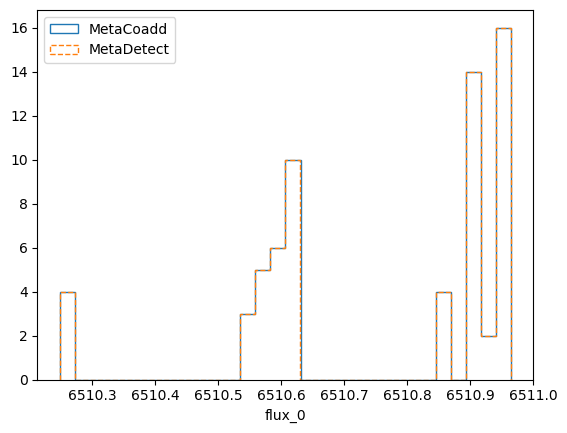

In [37]:
key = "1p"
good_mc = (final_cat[key][f"{model}_flags"] == 0) & (final_cat[key][f"{model}_s2n"] > 10)
good_md = (res[key][f"{model}_flags"] == 0) & (res[key][f"{model}_s2n"] > 10)
plt.hist(final_cat[key][f"{model}_flux_0"][good_mc], 30, histtype="step", label="MetaCoadd")
if len(mbobs) == 1:
    plt.hist(res[key][f"{model}_band_flux"][good_md], 30, histtype="step", label="MetaDetect", linestyle="--")
else:
    plt.hist(res[key][f"{model}_band_flux"][good_md, 0], 30, histtype="step", label="MetaDetect", linestyle="--")
plt.xlabel("flux_0")
plt.legend()

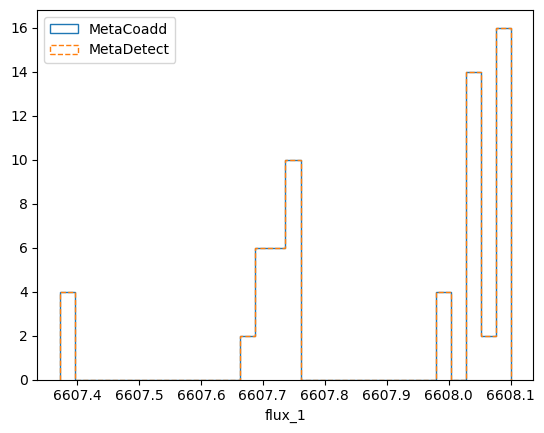

In [38]:
if len(mbobs) > 1:
    key = "1p"
    good_mc = (final_cat[key][f"{model}_flags"] == 0) & (final_cat[key][f"{model}_s2n"] > 10)
    good_md = (res[key][f"{model}_flags"] == 0) & (res[key][f"{model}_s2n"] > 10)
    plt.hist(final_cat[key][f"{model}_flux_1"][good_mc], 30, histtype="step", label="MetaCoadd")
    plt.hist(res[key][f"{model}_band_flux"][good_md, 1], 30, histtype="step", label="MetaDetect", linestyle="--")
    plt.xlabel("flux_1")
    plt.legend()

In [39]:
final_cat[key][f"{model}_g1"]

array([0.02995139, 0.02995366, 0.02995587, 0.02996199, 0.0299579 ,
       0.02996007, 0.02996449, 0.02996658, 0.02996015, 0.0299512 ,
       0.02995362, 0.02995572, 0.0299579 , 0.02996221, 0.02996461,
       0.02996648, 0.02995133, 0.02995352, 0.02995579, 0.02995793,
       0.02996034, 0.02996235, 0.02996445, 0.02996645, 0.02995134,
       0.02995328, 0.02995585, 0.02995793, 0.02996015, 0.02996238,
       0.02996456, 0.0299665 , 0.02995131, 0.02995347, 0.02995569,
       0.02995783, 0.02996015, 0.02996209, 0.0299668 , 0.0299645 ,
       0.02995134, 0.02995773, 0.0299669 , 0.02995329, 0.02995566,
       0.02995981, 0.02996201, 0.02996441, 0.02995356, 0.0299559 ,
       0.02996678, 0.02995113, 0.02995805, 0.02995996, 0.02996229,
       0.02996431, 0.02995365, 0.02995124, 0.02995548, 0.02995791,
       0.02996001, 0.02996205, 0.0299643 , 0.02996692])

In [40]:
res[key][f"{model}_g"][:, 0]

array([0.02995139, 0.02995366, 0.02995587, 0.02996199, 0.02995788,
       0.02996007, 0.0299645 , 0.02996659, 0.02996015, 0.02995117,
       0.02995362, 0.02995572, 0.0299579 , 0.02996221, 0.02996461,
       0.02996648, 0.02995133, 0.02995352, 0.02995579, 0.02995792,
       0.02996034, 0.02996235, 0.02996445, 0.02996645, 0.02995134,
       0.02995328, 0.02995585, 0.02995792, 0.02996015, 0.02996238,
       0.02996456, 0.0299665 , 0.02995131, 0.02995347, 0.02995569,
       0.02995784, 0.02996015, 0.02996209, 0.0299668 , 0.0299645 ,
       0.02995133, 0.02995783, 0.0299669 , 0.02995329, 0.02995566,
       0.02995981, 0.02996201, 0.02996441, 0.02995356, 0.0299559 ,
       0.02996679, 0.02995113, 0.02995805, 0.02995996, 0.02996228,
       0.02996431, 0.02995365, 0.02995125, 0.02995548, 0.02995791,
       0.02996001, 0.02996205, 0.0299643 , 0.02996693])

In [41]:
res["noshear"][f"{model}_T"]

array([0.13030523, 0.13030522, 0.13030522, 0.13030524, 0.13030524,
       0.13030523, 0.13030524, 0.13030522, 0.13030524, 0.13030522,
       0.1303052 , 0.13030523, 0.13030524, 0.13030522, 0.13030524,
       0.13030523, 0.13030524, 0.13030524, 0.13030523, 0.13030523,
       0.13030522, 0.13030523, 0.13030522, 0.13030524, 0.13030522,
       0.13030523, 0.13030522, 0.13030526, 0.13030523, 0.13030522,
       0.13030525, 0.13030523, 0.13030522, 0.13030526, 0.13030524,
       0.13030521, 0.13030525, 0.13030522, 0.13030522, 0.13030523,
       0.13030524, 0.13030522, 0.13030523, 0.13030521, 0.13030523,
       0.13030522, 0.13030523, 0.13030523, 0.13030521, 0.13030521,
       0.13030523, 0.13030523, 0.1303052 , 0.13030523, 0.13030521,
       0.13030525, 0.13030526, 0.13030522, 0.13030524, 0.13030524,
       0.13030526, 0.13030523, 0.13030523, 0.13030525])

In [42]:
final_cat["noshear"][f"{model}_T"]

array([0.13030523, 0.13030522, 0.13030522, 0.13030524, 0.13030524,
       0.13030523, 0.13030524, 0.13030522, 0.13030524, 0.13030522,
       0.1303052 , 0.13030523, 0.13030524, 0.13030522, 0.13030524,
       0.13030523, 0.13030524, 0.13030524, 0.13030523, 0.13030523,
       0.13030522, 0.13030523, 0.13030522, 0.13030524, 0.13030522,
       0.13030523, 0.13030522, 0.13030526, 0.13030523, 0.13030522,
       0.13030525, 0.13030523, 0.13030522, 0.13030526, 0.13030524,
       0.13030521, 0.13030525, 0.13030522, 0.13030522, 0.13030523,
       0.13030524, 0.13030522, 0.13030523, 0.13030521, 0.13030523,
       0.13030522, 0.13030523, 0.13030523, 0.13030521, 0.13030521,
       0.13030523, 0.13030523, 0.1303052 , 0.13030523, 0.13030521,
       0.13030525, 0.13030526, 0.13030522, 0.13030524, 0.13030524,
       0.13030526, 0.13030523, 0.13030523, 0.13030525])

In [43]:
mprofile_ngmix = np.loadtxt("../examples/mprofile_ngmix.dat", skiprows=1, usecols=(1, 2), unpack=True)
mprofile_mcoadd = np.loadtxt("../examples/mprofile_metacoadd.dat", skiprows=1, usecols=(1, 2), unpack=True)

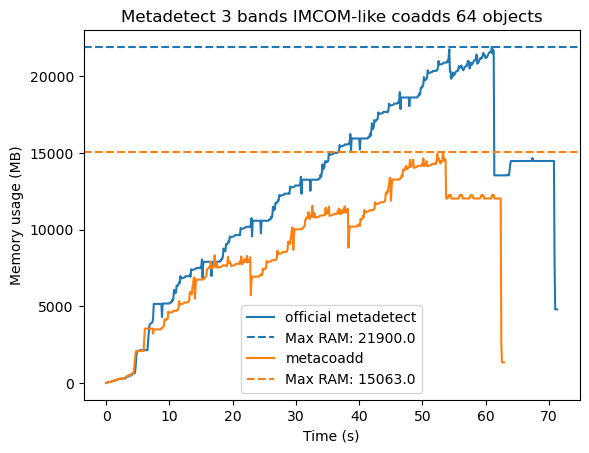

In [44]:
plt.plot(mprofile_ngmix[1]-np.min(mprofile_ngmix[1]), mprofile_ngmix[0], color="C0", label="official metadetect")
plt.axhline(np.max(mprofile_ngmix[0]), color="C0", linestyle="--", label=f"Max RAM: {np.round(np.max(mprofile_ngmix[0]))}")
plt.plot(mprofile_mcoadd[1]-np.min(mprofile_mcoadd[1]), mprofile_mcoadd[0], color="C1", label="metacoadd")
plt.axhline(np.max(mprofile_mcoadd[0]), color="C1", linestyle="--", label=f"Max RAM: {np.round(np.max(mprofile_mcoadd[0]))}")
plt.xlabel("Time (s)")
plt.ylabel("Memory usage (MB)")
plt.title("Metadetect 3 bands IMCOM-like coadds 64 objects")
plt.legend()